Setup and imports

In [13]:
import torch
import torchvision
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os

In [ ]:
RAND_SEED = 42
random.seed(RAND_SEED)
np.random.seed(RAND_SEED)
torch.manual_seed(RAND_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


Phase 1: Data exploration & binary label transformation

In [ ]:
df = pd.read_csv('../data/train.csv')
df.head(5)

(3662, 2)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


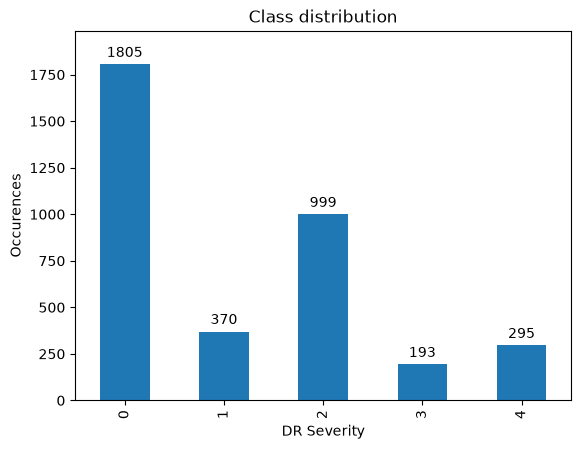

In [ ]:
class_counts = df['diagnosis'].value_counts().sort_index()

ax = class_counts.plot(kind='bar', title='Class distribution', xlabel = 'DR Severity', ylabel='Occurences')
ax.bar_label(ax.containers[0], label_type='edge', padding=3)
ax.margins(y=0.1)

plt.show()

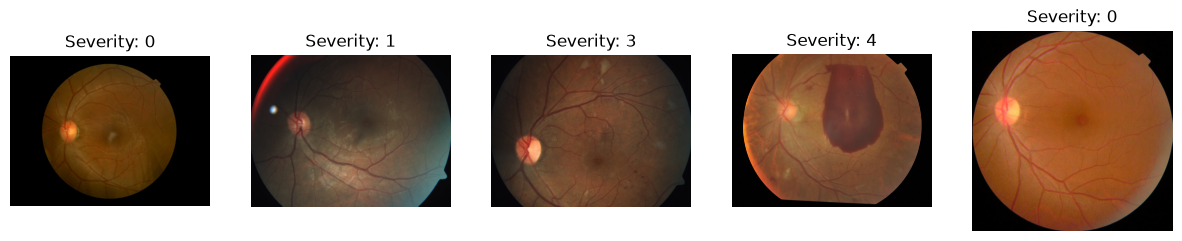

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_rows = df.sample(5, random_state=RAND_SEED)

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = f"../data/train_images/{row['id_code']}.png"
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"Severity: {row['diagnosis']}")
    ax.axis('off')
plt.show()

In [18]:
#Reduce to binary labels
df['binary_label'] = (df['diagnosis'] > 0).astype(int)

print(df['binary_label'].value_counts())
print(f"\nClass ratio: {df['binary_label'].value_counts(normalize=True)}")

binary_label
1    1857
0    1805
Name: count, dtype: int64

Class ratio: binary_label
1    0.5071
0    0.4929
Name: proportion, dtype: float64


Phase 2: Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

#Training data split
train_df, val_test_df = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df['binary_label'], 
    random_state=RAND_SEED
)

#Test and validation data split
val_df, test_df = train_test_split(
    val_test_df, 
    test_size=0.5,
    stratify=val_test_df['binary_label'], 
    random_state=RAND_SEED
)

train_balance, val_balance, test_balance = train_df['binary_label'].value_counts(normalize=True), val_df['binary_label'].value_counts(normalize=True), test_df['binary_label'].value_counts(normalize=True)

print(f'Training set: {len(train_df)}, Validation set: {len(val_df)}, Test set: {len(test_df)}')
print(f'\nTrain class balance:\n{train_balance}')
print(f"\nVal class balance:\n{val_balance}")
print(f"\nTest class balance:\n{test_balance}")

Training set: 2563, Validation set: 549, Test set: 550

Train class balance:
binary_label
1    0.507218
0    0.492782
Name: proportion, dtype: float64

Val class balance:
binary_label
1    0.506375
0    0.493625
Name: proportion, dtype: float64

Test class balance:
binary_label
1    0.507273
0    0.492727
Name: proportion, dtype: float64
